In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
# 1. Инициализация среды

# Создаем среду Taxi-v3 (дискретная задача)
env = gym.make("Taxi-v3")

# Количество состояний и действий
n_states = env.observation_space.n   # всего 500 состояний
n_actions = env.action_space.n       # всего 6 действий

print("n_states =", n_states, "n_actions =", n_actions)

n_states = 500 n_actions = 6


In [3]:
# 2. Инициализация политики

def initialize_policy(n_states, n_actions):
    """
    Создаем начальную (случайную) политику.
    policy[s][a] = вероятность выбрать действие a в состоянии s

    Инициализация равномерная:
    для каждого состояния вероятность всех действий одинаковая
    """
    policy = np.ones((n_states, n_actions)) / n_actions
    return policy


In [4]:
# 3. Генерация одной сессии

def generate_session(env, policy, t_max=10**4):
    """
    Играем один эпизод (сессию) в среде

    Возвращает:
    - states: список состояний
    - actions: список действий
    - total_reward: суммарная награда
    """
    states, actions = [], []
    total_reward = 0.0

    # Сброс среды
    s, _ = env.reset()

    for t in range(t_max):
        # Выбираем действие согласно вероятностной политике
        a = np.random.choice(n_actions, p=policy[s])

        # Выполняем действие
        new_s, r, done, _, _ = env.step(a)

        # Сохраняем историю
        states.append(s)
        actions.append(a)

        # Накопление награды
        total_reward += r

        # Переход в новое состояние
        s = new_s

        # Если эпизод завершен — выходим
        if done:
            break

    return states, actions, total_reward



In [5]:

# 4. Отбор лучших (элитных) сессий

def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Выбираем только лучшие сессии (top percentile по награде)

    Возвращаем:
    - elite_states: состояния из лучших сессий
    - elite_actions: действия из лучших сессий
    """

    # Порог: минимальная награда для попадания в элиту
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    # Проходим по всем сессиям
    for i in range(len(states_batch)):
        # Если награда >= порога — берём эту сессию
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

In [6]:
# 5. Обновление политики

def get_new_policy(elite_states, elite_actions):
    """
    Строим новую политику на основе элитных данных

    Идея:
    вероятность действия пропорциональна частоте его появления
    """

    # Счётчик действий для каждого состояния
    new_policy = np.zeros((n_states, n_actions))

    # Считаем частоты действий
    for s, a in zip(elite_states, elite_actions):
        new_policy[s][a] += 1

    # Нормализация (превращаем в вероятности)
    for s in range(n_states):
        if np.sum(new_policy[s]) == 0:
            # Если состояние не встречалось — оставляем равномерное распределение
            new_policy[s] = np.ones(n_actions) / n_actions
        else:
            # Делим на сумму → получаем вероятности
            new_policy[s] /= np.sum(new_policy[s])

    return new_policy

In [7]:
# 6. Визуализация обучения

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    Отображает:
    - среднюю награду
    - порог элитных сессий
    - распределение наград
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)

    # Лог для графика
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])

    # График обучения
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean reward')
    plt.plot(list(zip(*log))[1], label='Threshold')
    plt.legend()
    plt.grid()

    # Гистограмма наград
    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([threshold], [0], [100], color='red')
    plt.grid()

    print(f"mean reward = {mean_reward:.3f}, threshold = {threshold:.3f}")
    plt.show()


mean reward = -10964.808, threshold = -7673.000


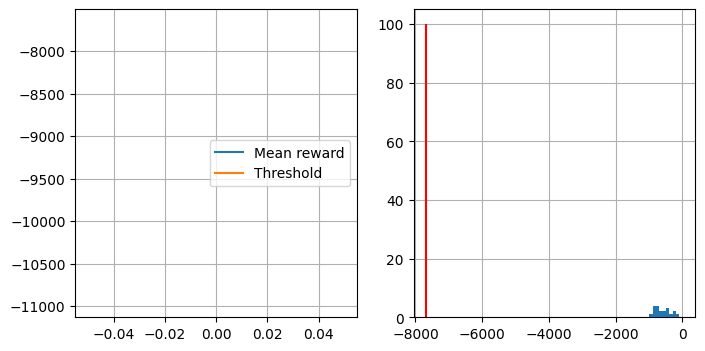

mean reward = -5458.872, threshold = -3998.000


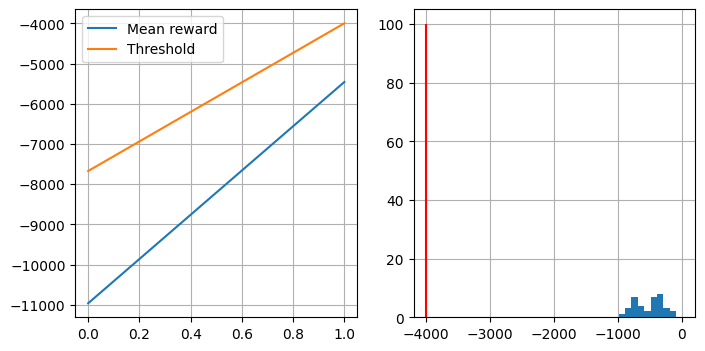

mean reward = -2916.024, threshold = -2154.000


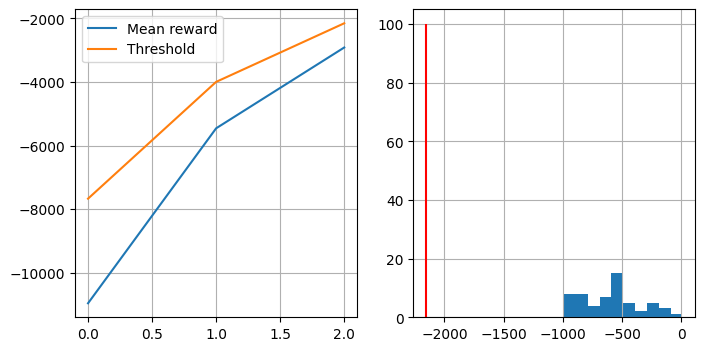

mean reward = -1778.928, threshold = -1384.000


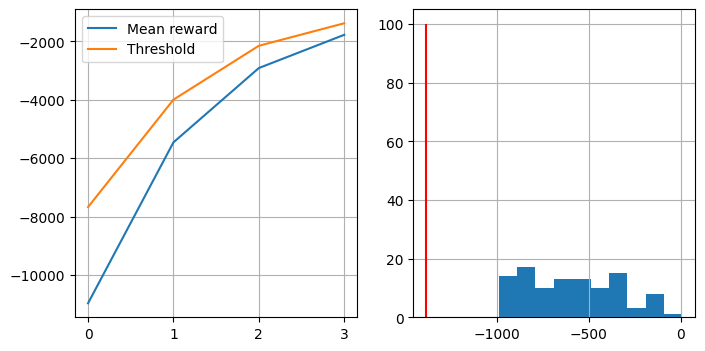

mean reward = -877.164, threshold = -737.500


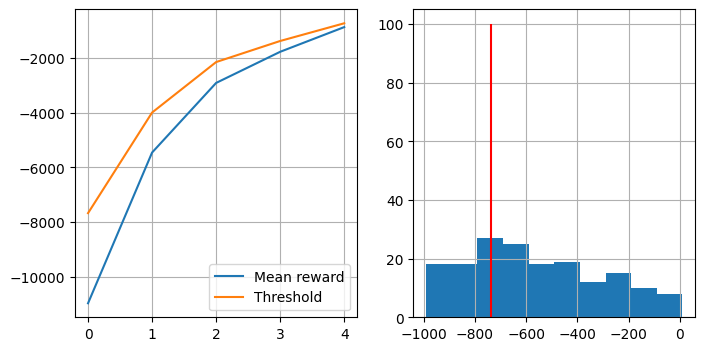

mean reward = -646.216, threshold = -564.000


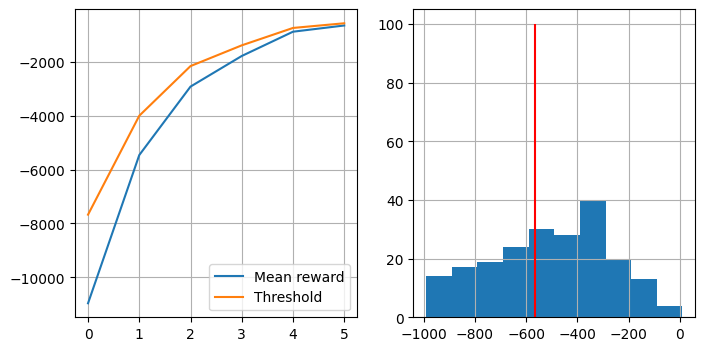

mean reward = -486.240, threshold = -429.500


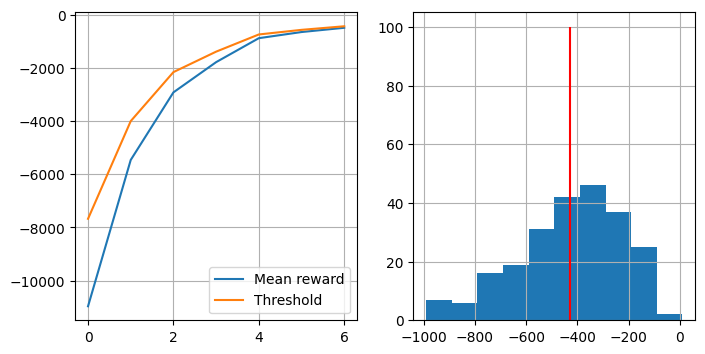

mean reward = -349.640, threshold = -313.000


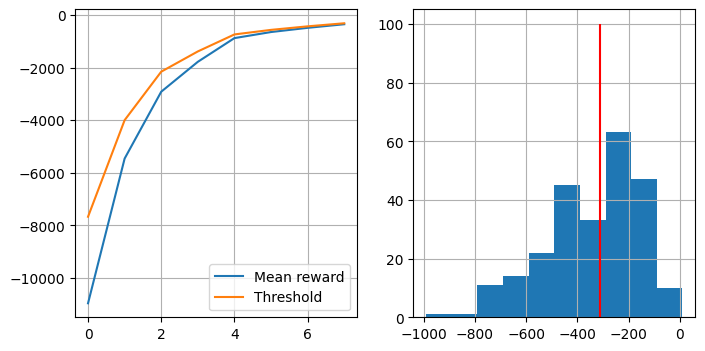

mean reward = -247.596, threshold = -227.000


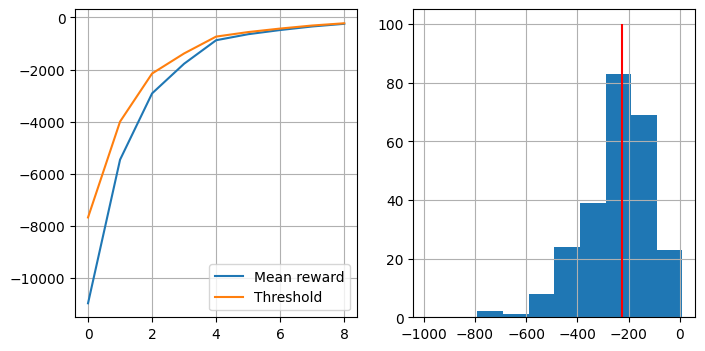

mean reward = -193.952, threshold = -180.000


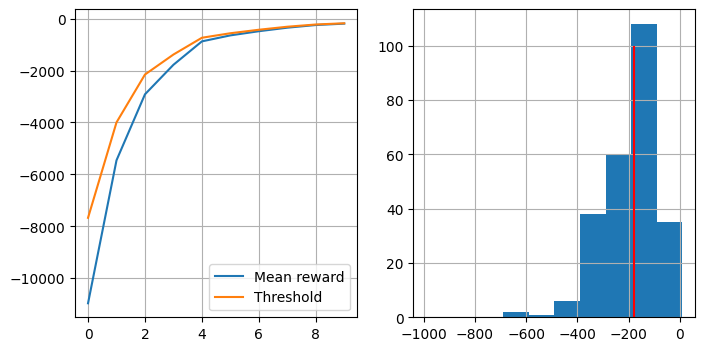

mean reward = -155.480, threshold = -132.000


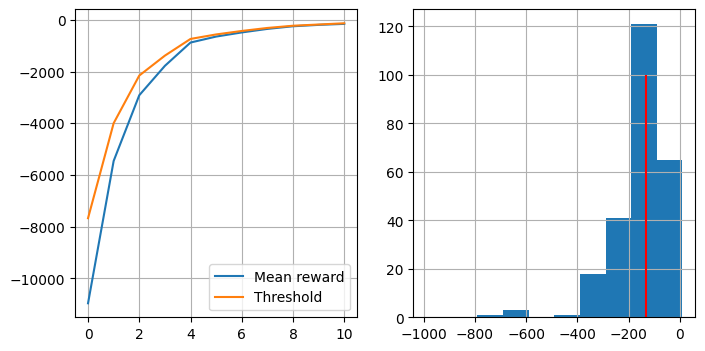

mean reward = -120.136, threshold = -107.000


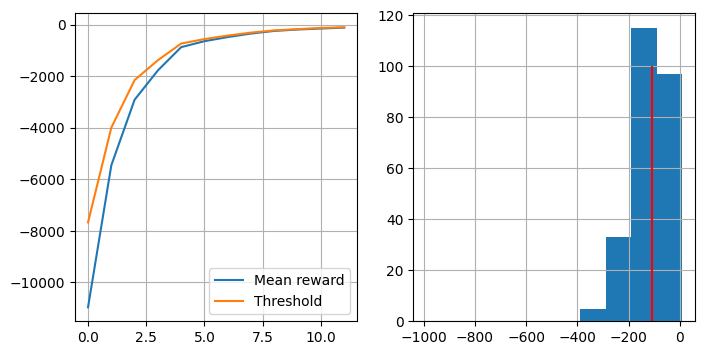

mean reward = -102.616, threshold = -81.500


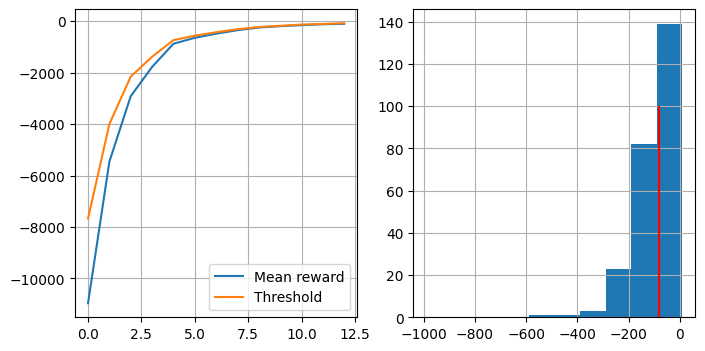

mean reward = -83.736, threshold = -72.500


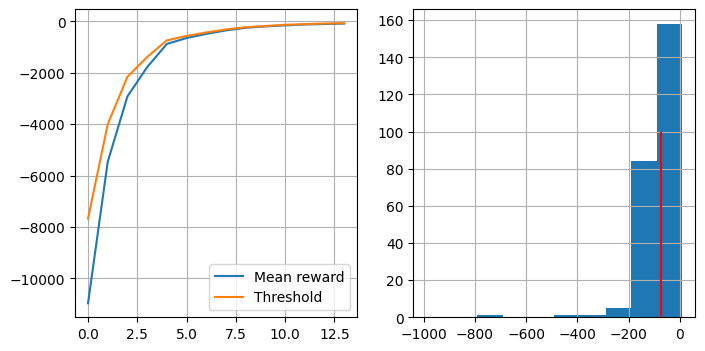

mean reward = -64.332, threshold = -53.500


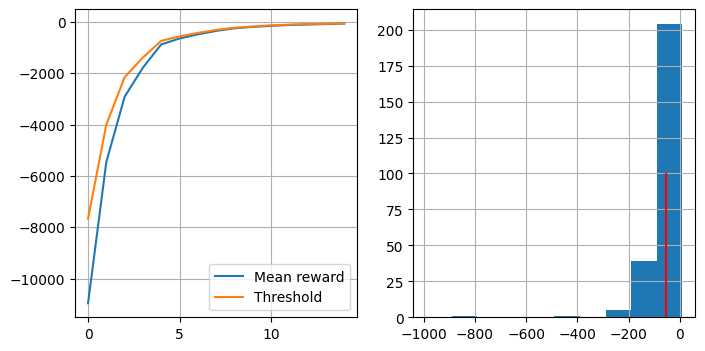

mean reward = -54.572, threshold = -40.500


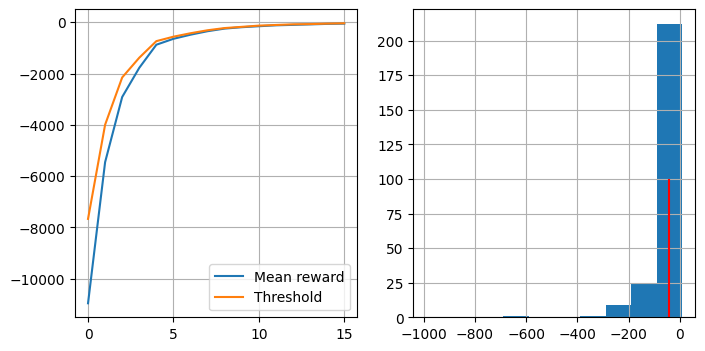

mean reward = -57.872, threshold = -36.000


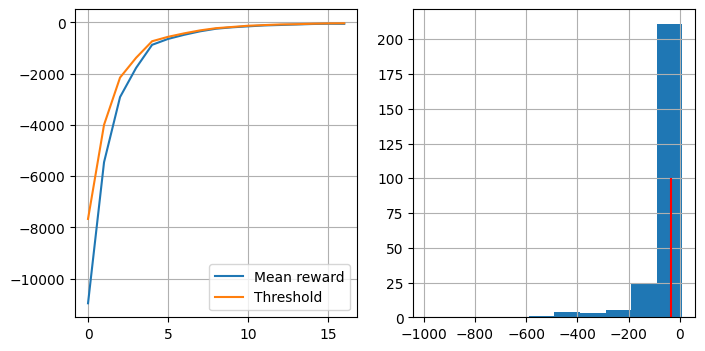

mean reward = -51.404, threshold = -28.000


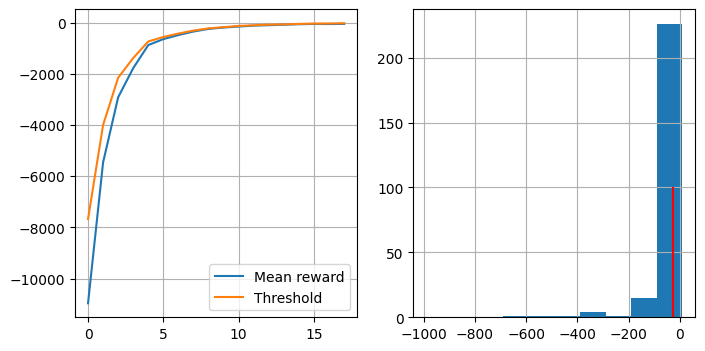

mean reward = -50.228, threshold = -22.000


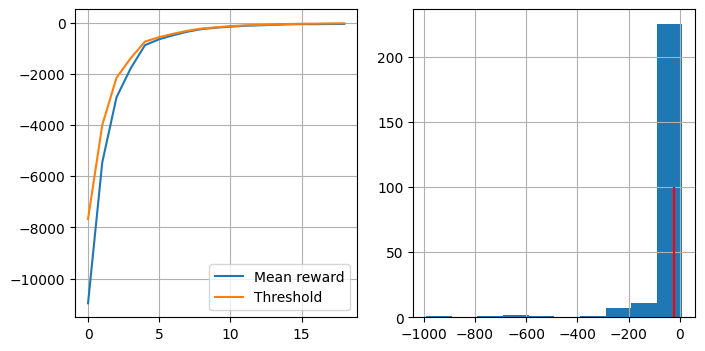

mean reward = -41.208, threshold = -14.000


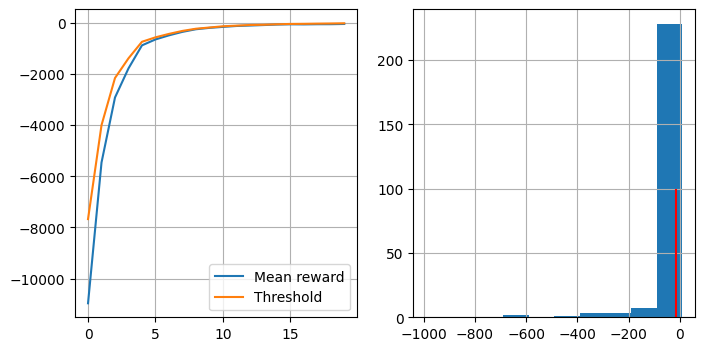

mean reward = -33.852, threshold = -9.000


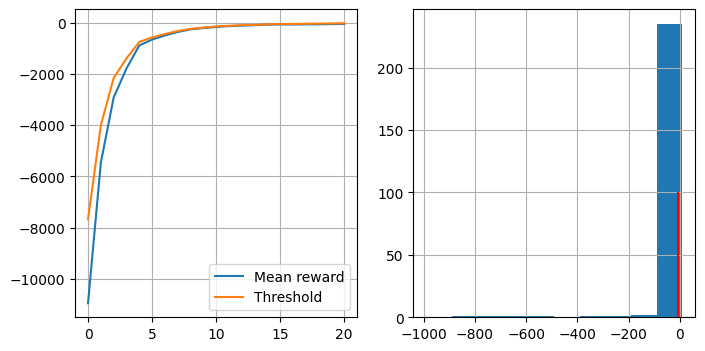

mean reward = -16.048, threshold = -6.000


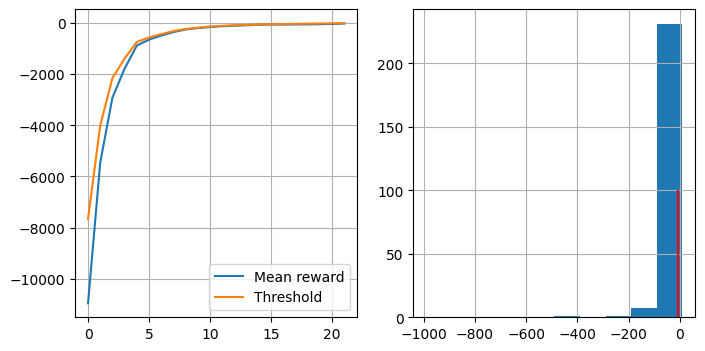

mean reward = -33.316, threshold = -5.000


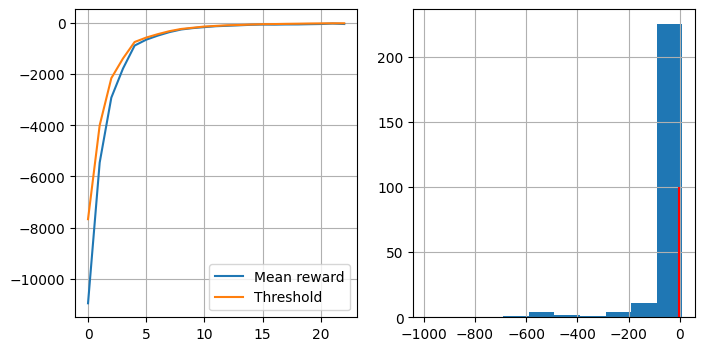

mean reward = -19.620, threshold = -2.000


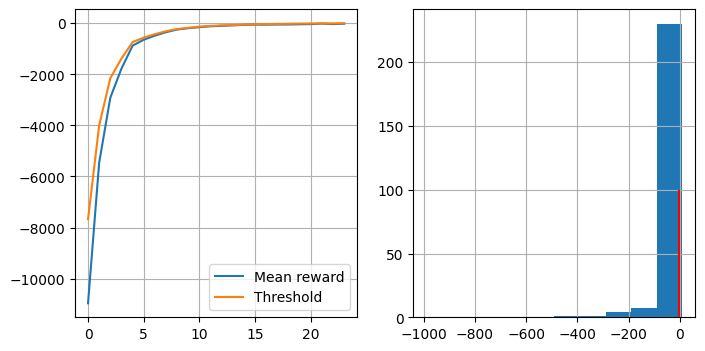

mean reward = -19.908, threshold = -1.000


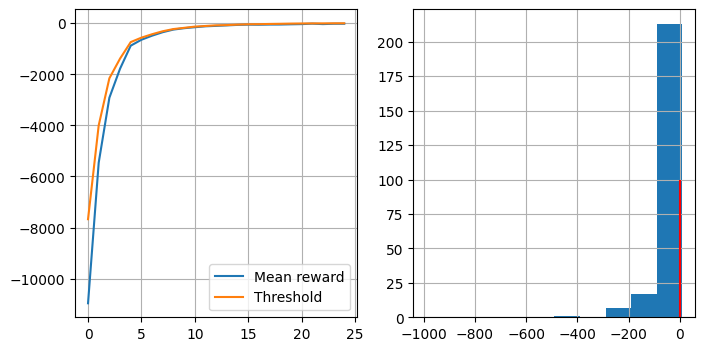

mean reward = -26.456, threshold = -1.000


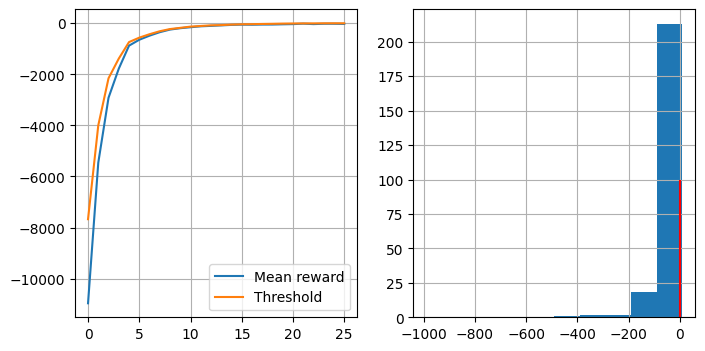

mean reward = -23.344, threshold = 0.000


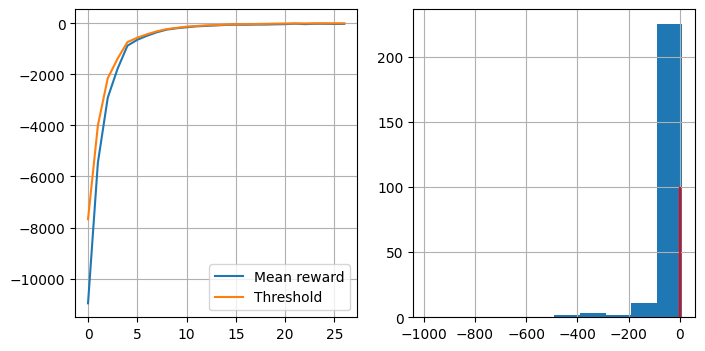

mean reward = -24.372, threshold = 2.000


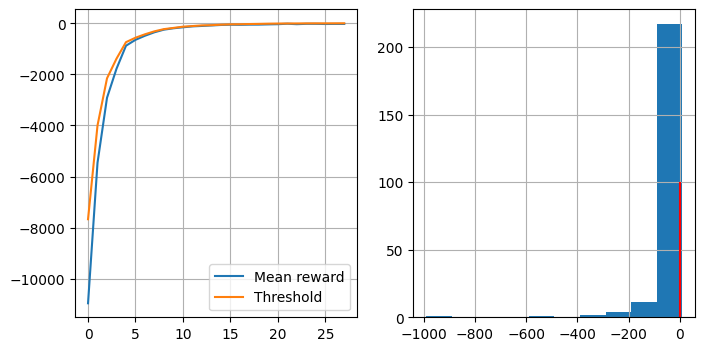

mean reward = -22.980, threshold = 3.000


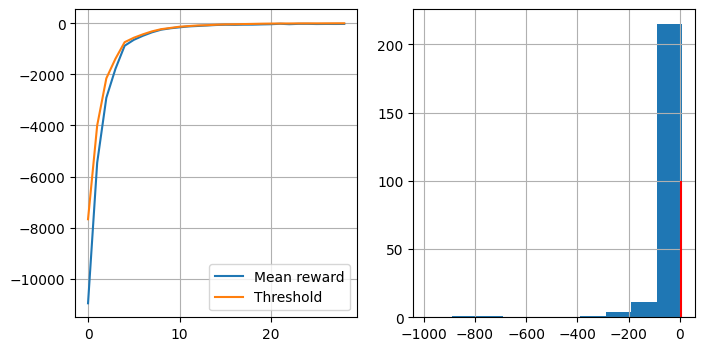

mean reward = -37.260, threshold = 2.000


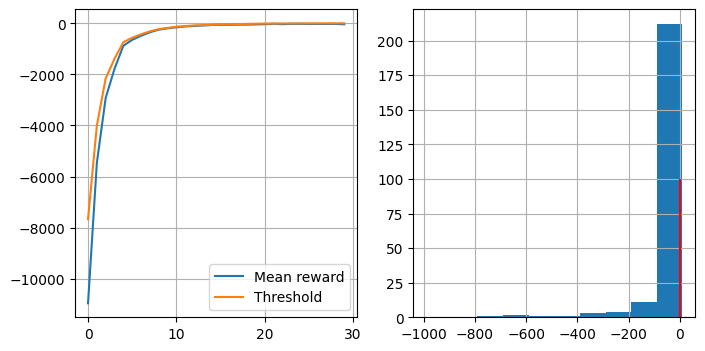

mean reward = -24.688, threshold = 2.000


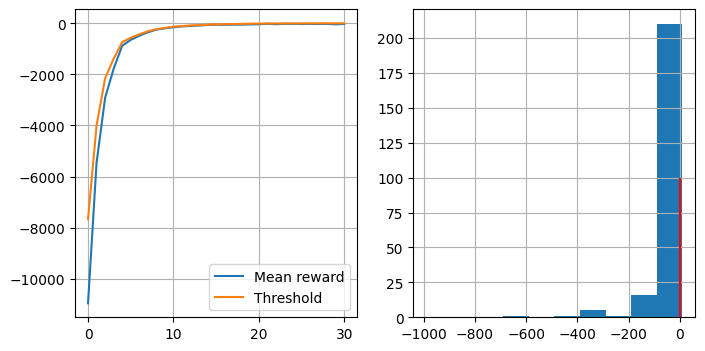

mean reward = -16.788, threshold = 4.000


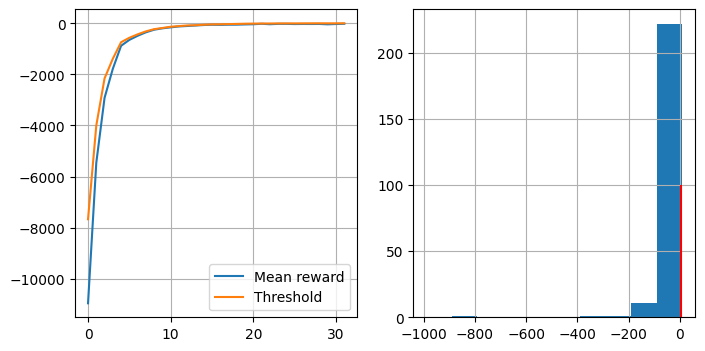

mean reward = -33.432, threshold = 4.000


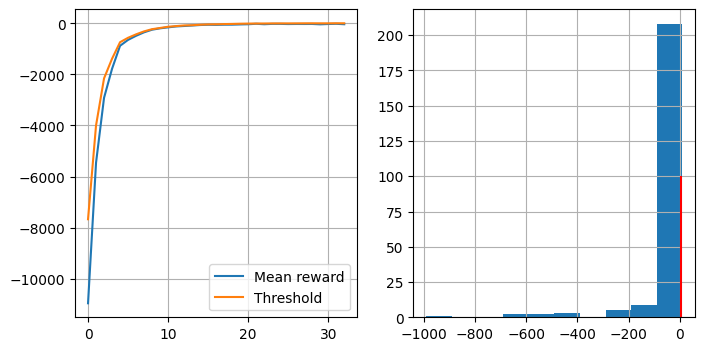

mean reward = -18.592, threshold = 3.000


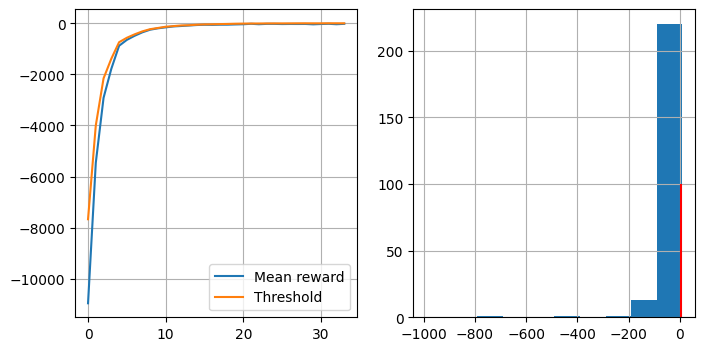

mean reward = -24.956, threshold = 4.000


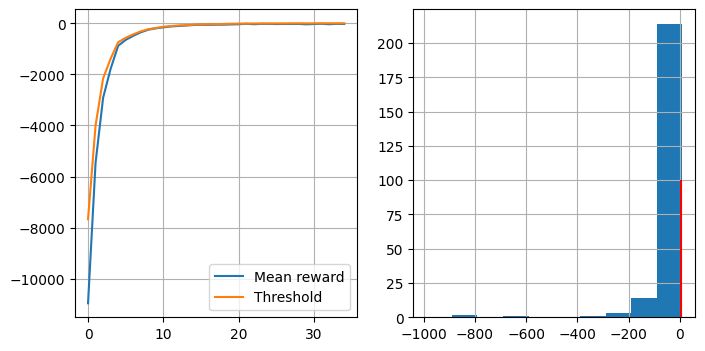

mean reward = -25.124, threshold = 4.000


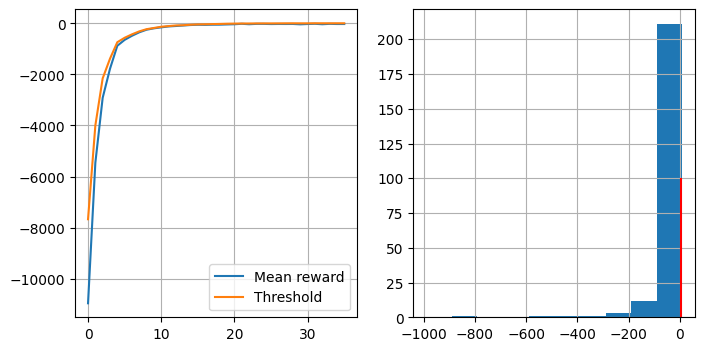

mean reward = -26.312, threshold = 0.000


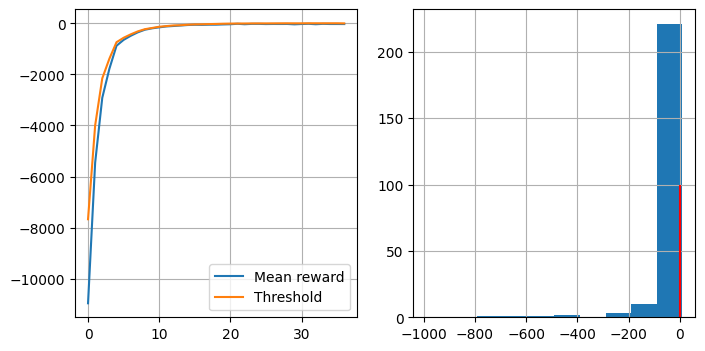

mean reward = -25.672, threshold = 5.000


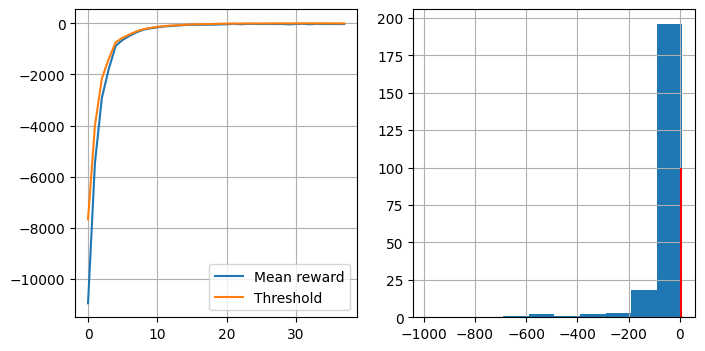

mean reward = -28.080, threshold = 4.000


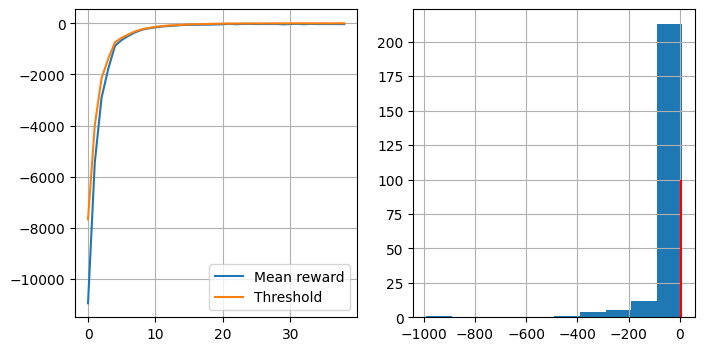

mean reward = -29.820, threshold = 4.000


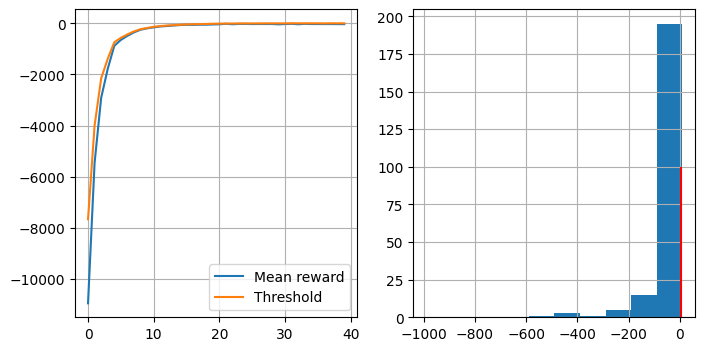

mean reward = -24.060, threshold = 5.000


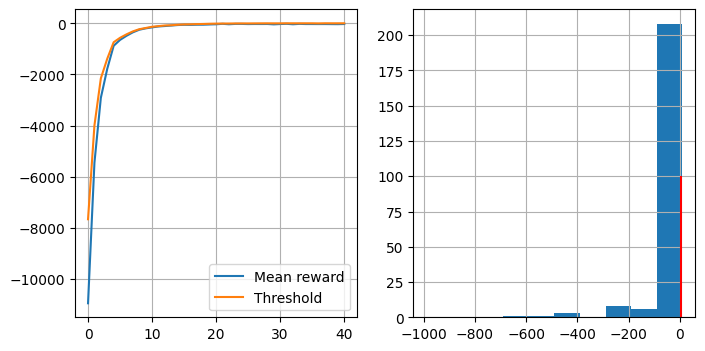

mean reward = -23.776, threshold = 5.000


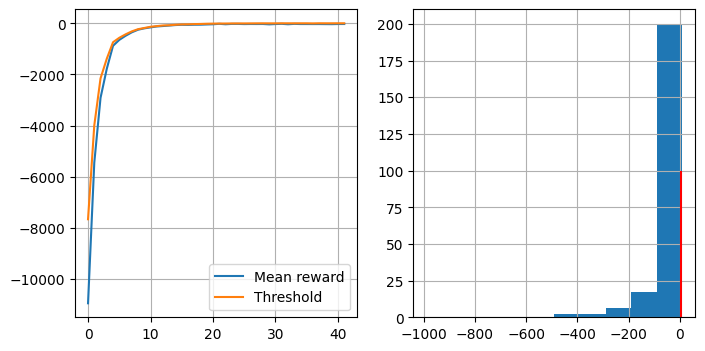

mean reward = -27.516, threshold = 5.000


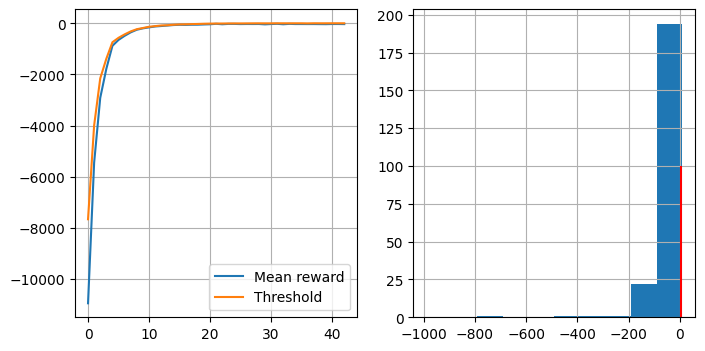

mean reward = -32.044, threshold = 4.000


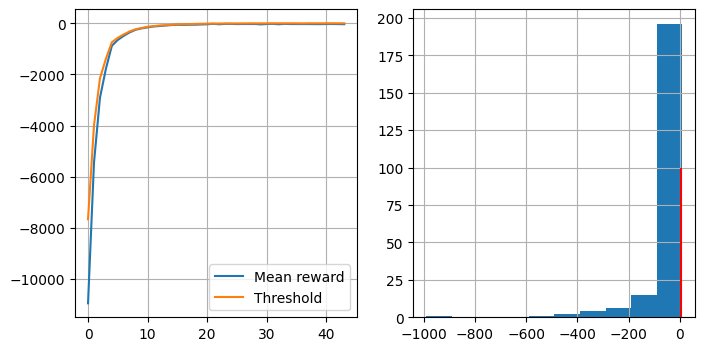

mean reward = -34.416, threshold = 6.000


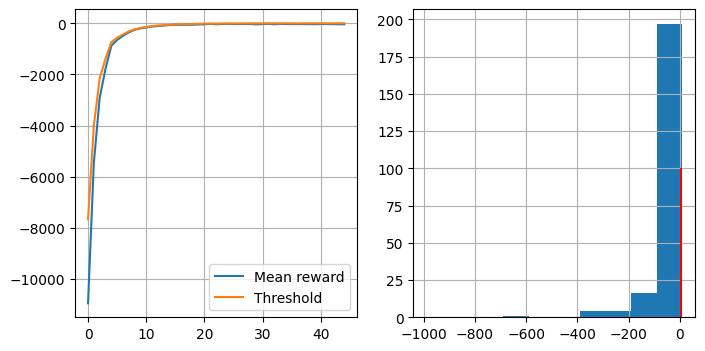

mean reward = -39.792, threshold = 0.500


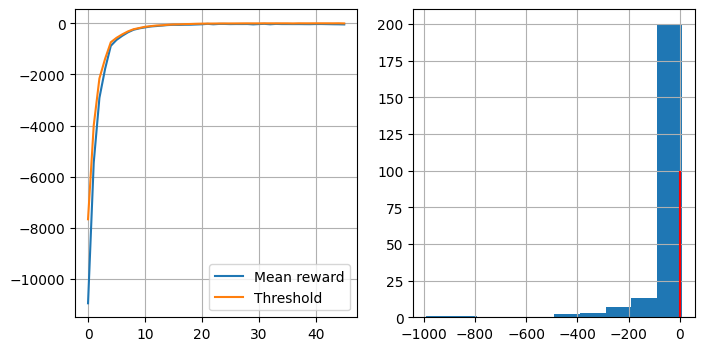

mean reward = -26.300, threshold = 6.000


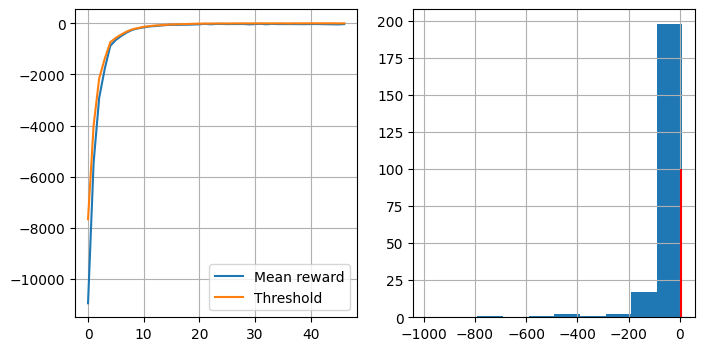

mean reward = -35.848, threshold = 4.000


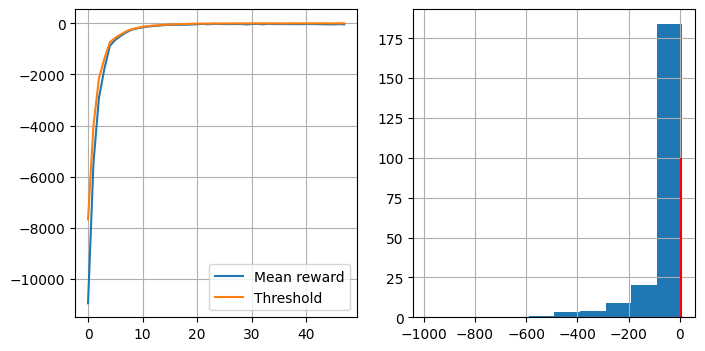

mean reward = -49.760, threshold = 6.000


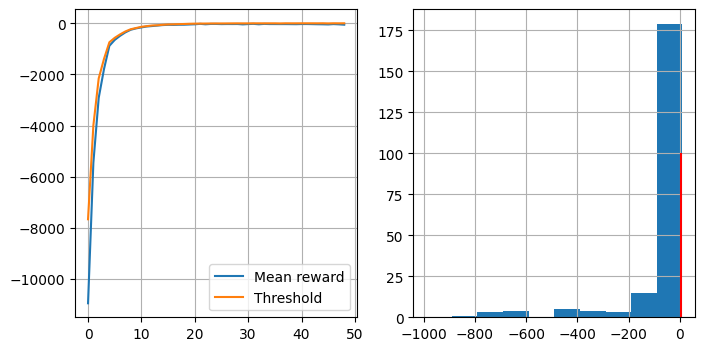

mean reward = -66.532, threshold = 4.000


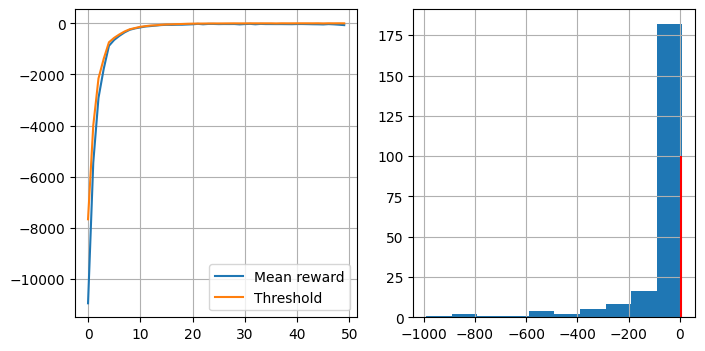

mean reward = -98.828, threshold = 1.000


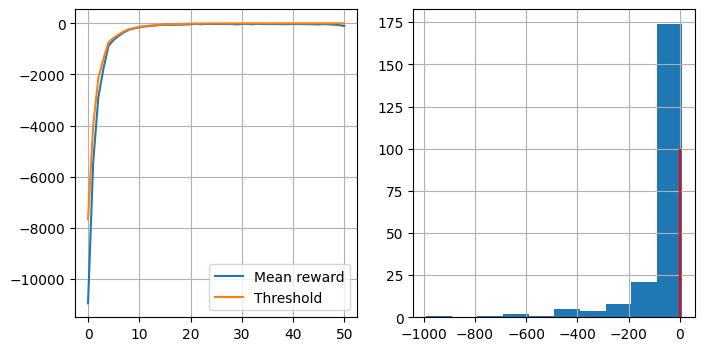

mean reward = -80.824, threshold = 5.000


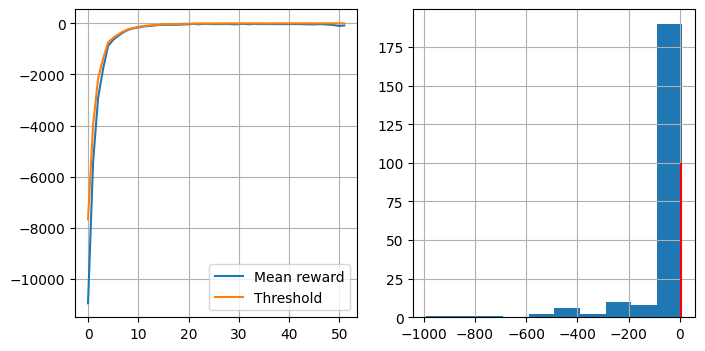

mean reward = -66.684, threshold = 4.000


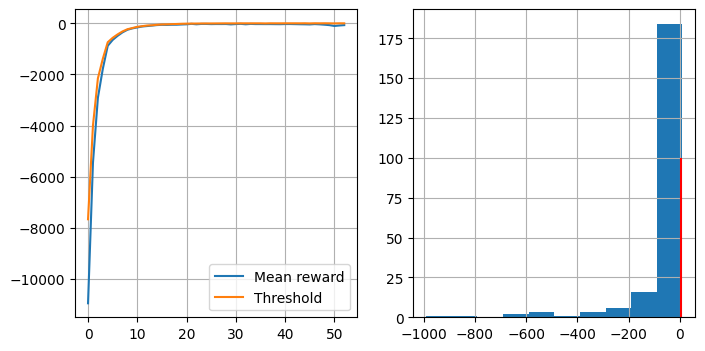

mean reward = -83.200, threshold = 5.000


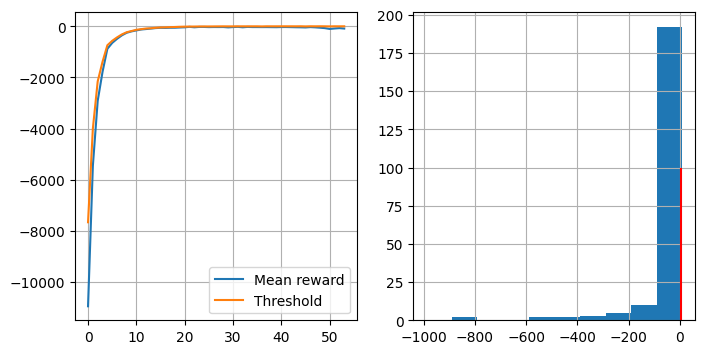

mean reward = -64.536, threshold = 3.000


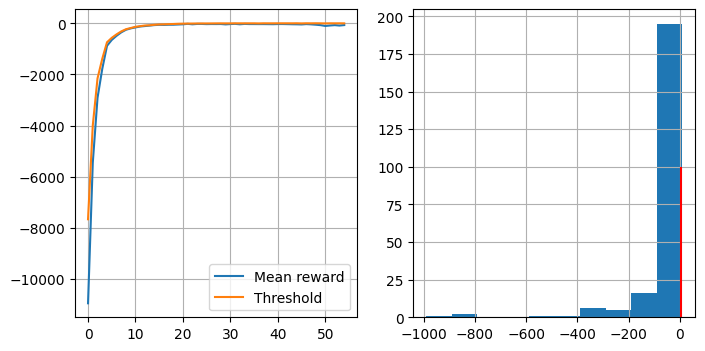

mean reward = -84.864, threshold = 4.500


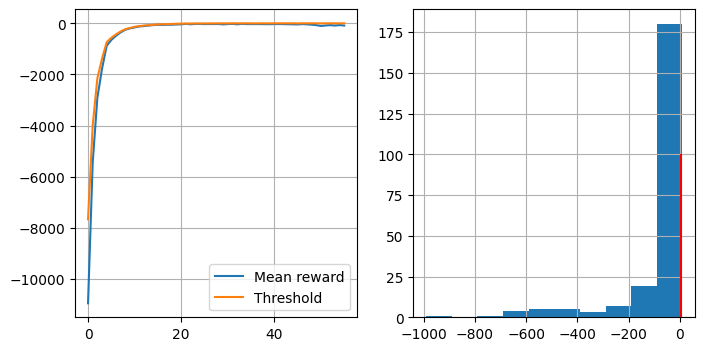

mean reward = -50.980, threshold = 5.000


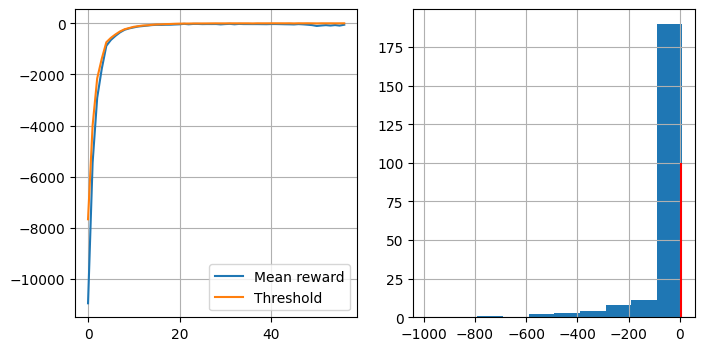

mean reward = -63.512, threshold = 6.000


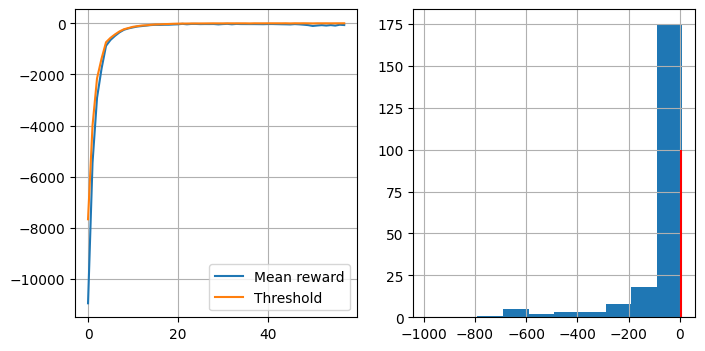

mean reward = -75.608, threshold = -2.500


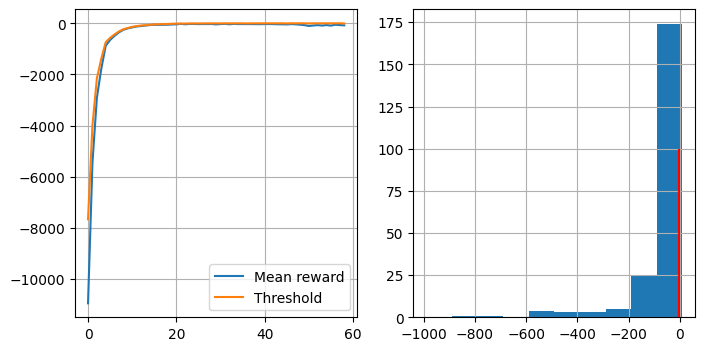

mean reward = -79.484, threshold = 4.000


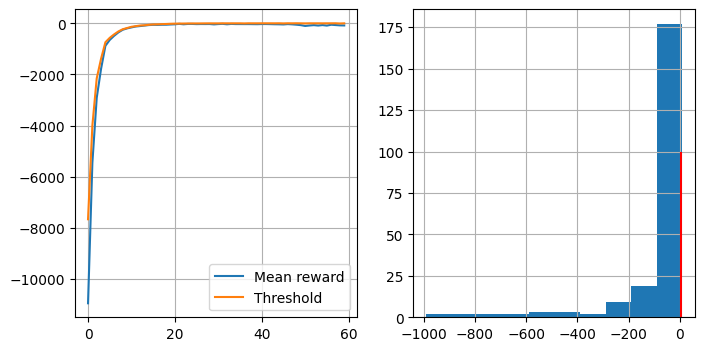

mean reward = -49.464, threshold = 6.000


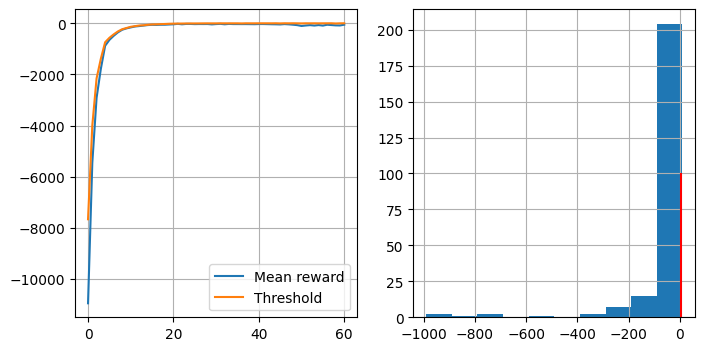

mean reward = -60.856, threshold = 5.500


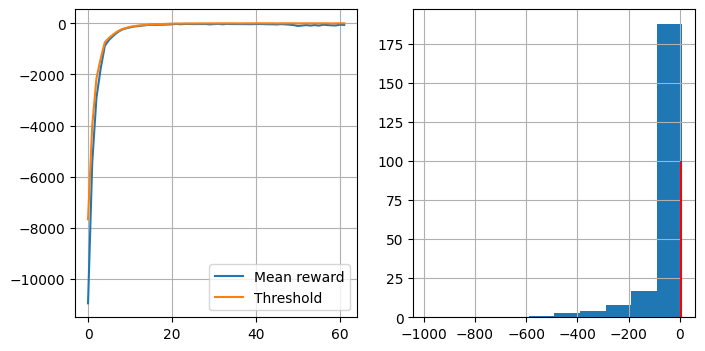

mean reward = -71.516, threshold = 6.000


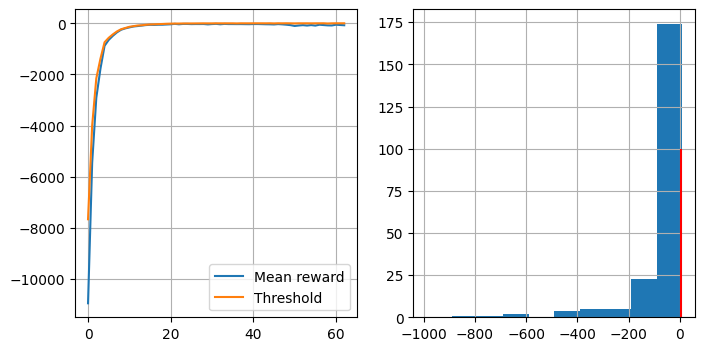

mean reward = -54.104, threshold = 6.000


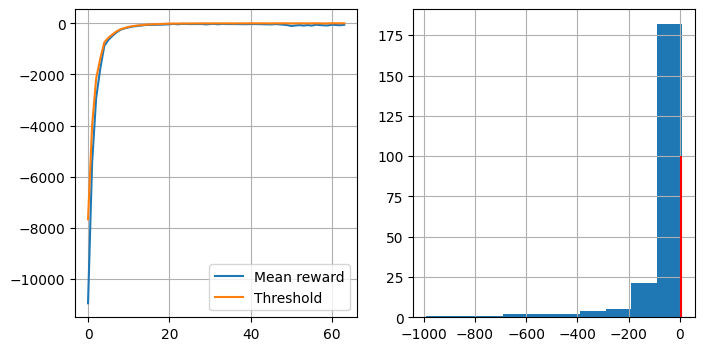

mean reward = -93.568, threshold = 1.500


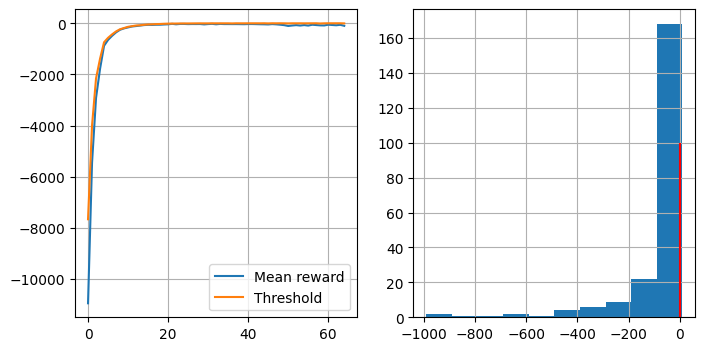

mean reward = -55.824, threshold = 2.500


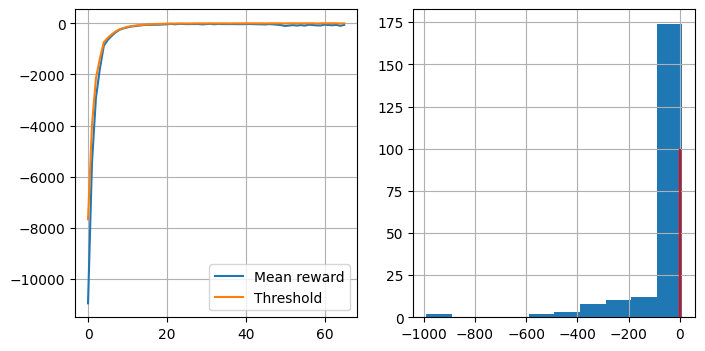

mean reward = -60.148, threshold = 5.500


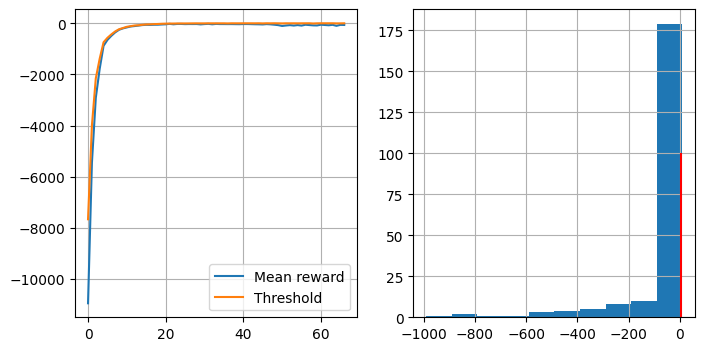

mean reward = -92.280, threshold = 3.000


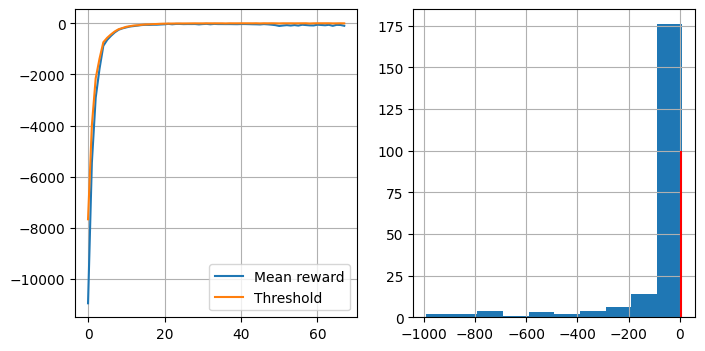

mean reward = -52.440, threshold = 4.000


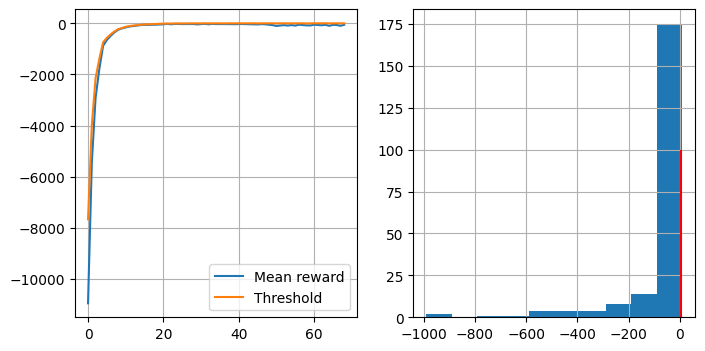

mean reward = -48.080, threshold = 6.000


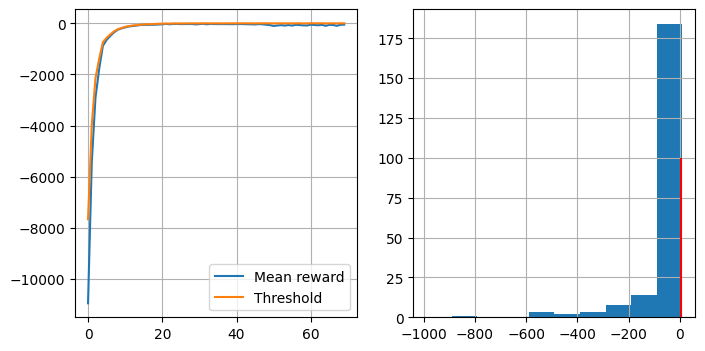

mean reward = -51.612, threshold = 6.000


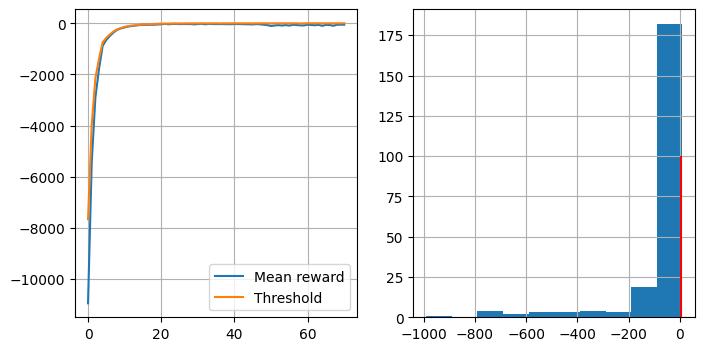

mean reward = -51.004, threshold = 4.500


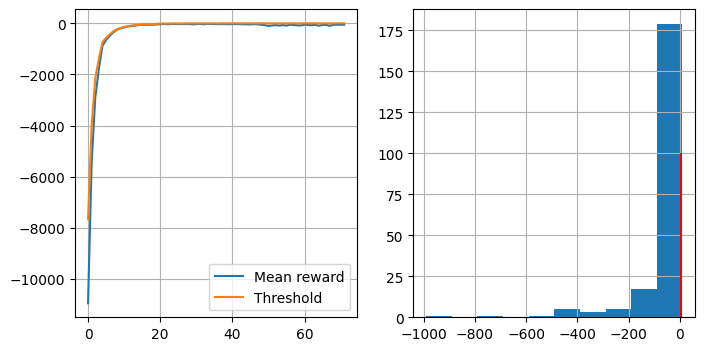

mean reward = -28.736, threshold = 5.500


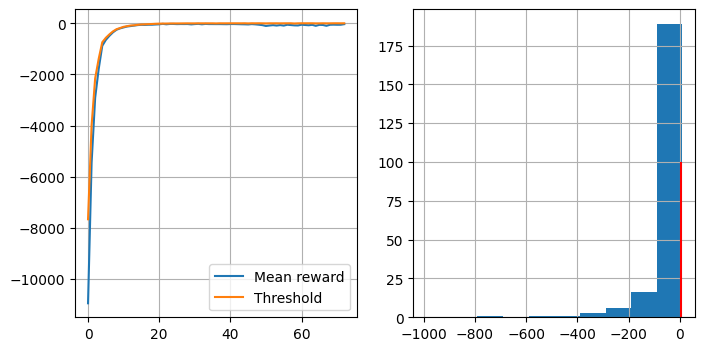

mean reward = -41.768, threshold = 5.000


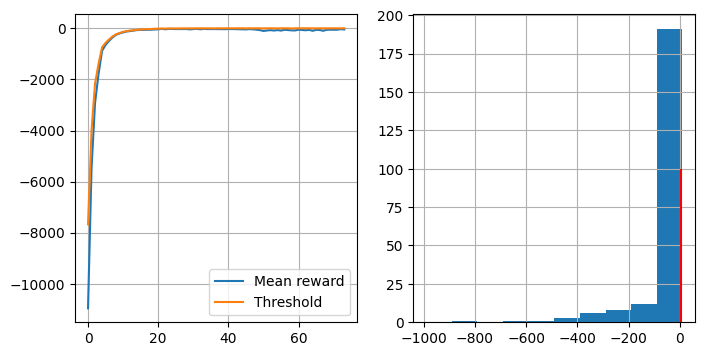

mean reward = -46.224, threshold = 5.000


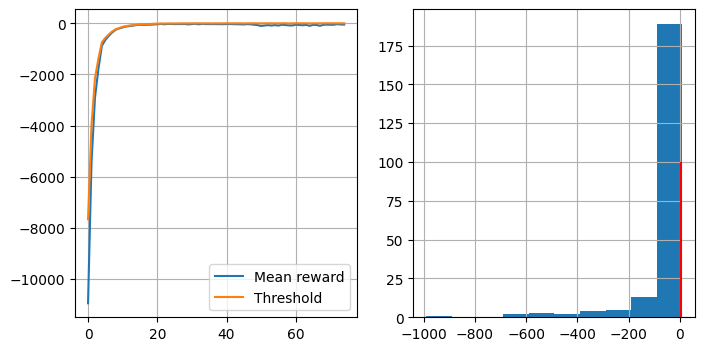

mean reward = -60.476, threshold = 6.000


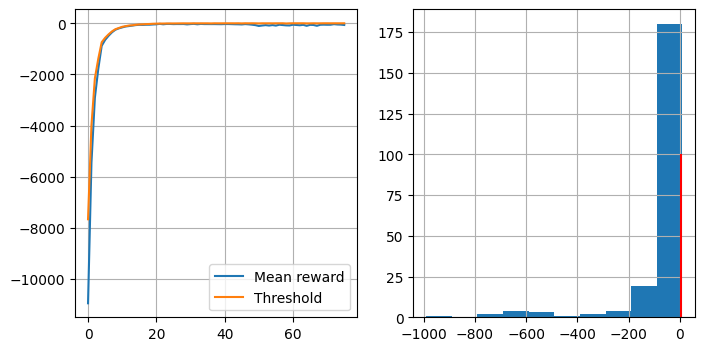

mean reward = -53.656, threshold = 6.000


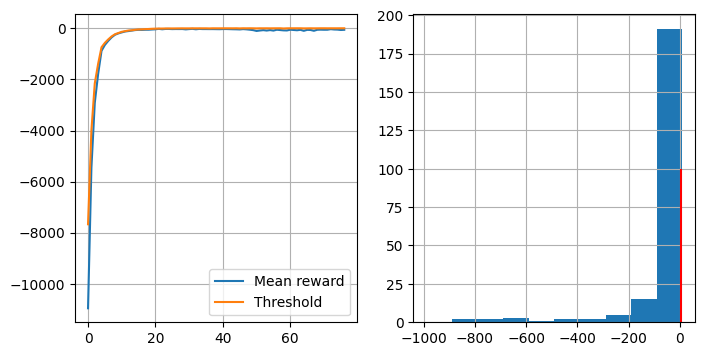

mean reward = -48.836, threshold = 4.500


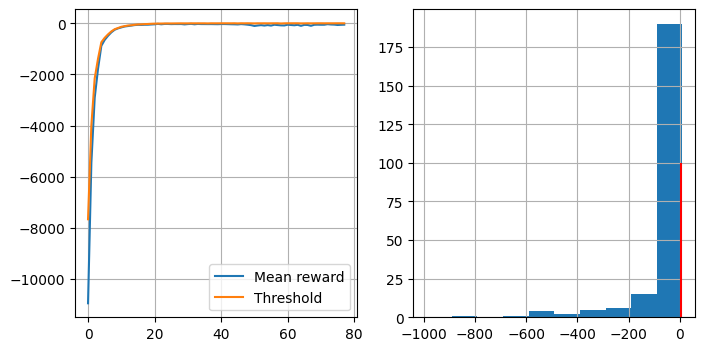

mean reward = -49.696, threshold = 5.000


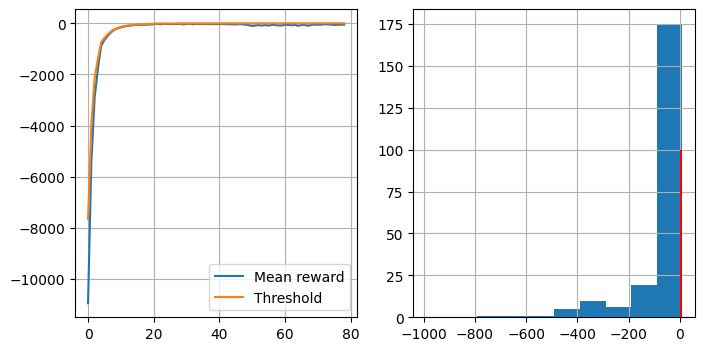

mean reward = -61.020, threshold = 6.000


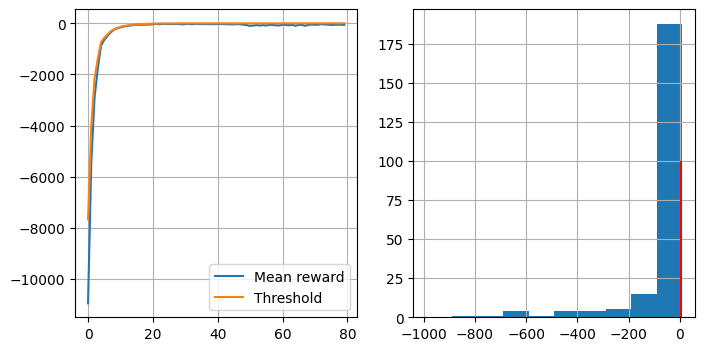

mean reward = -54.260, threshold = -3.500


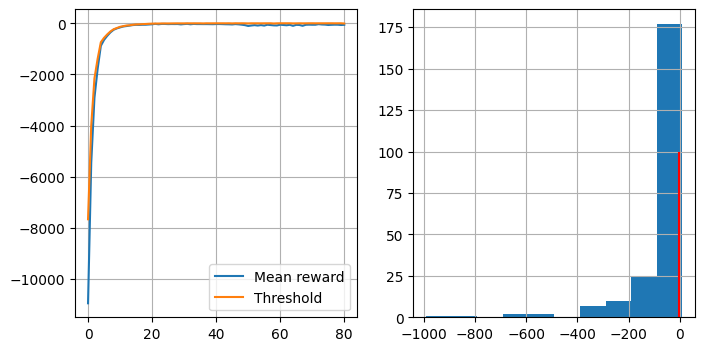

mean reward = -39.796, threshold = 6.000


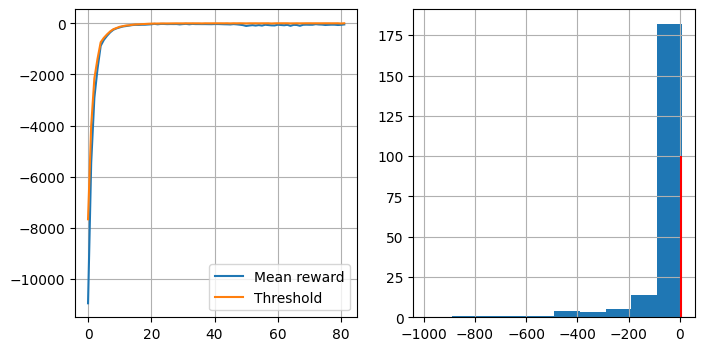

mean reward = -67.576, threshold = 5.000


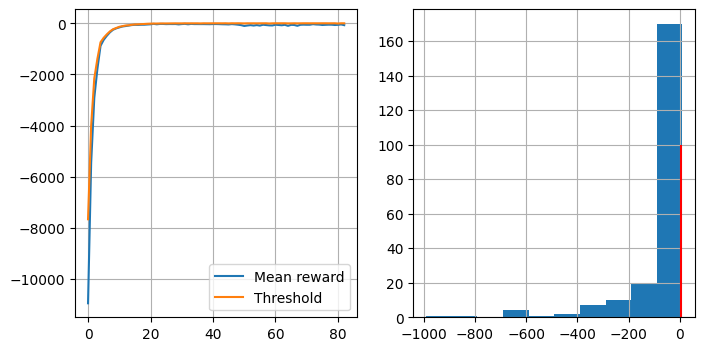

mean reward = -51.424, threshold = 5.500


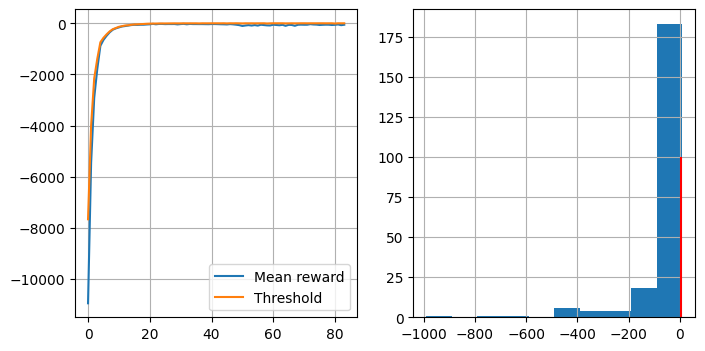

mean reward = -44.380, threshold = 6.000


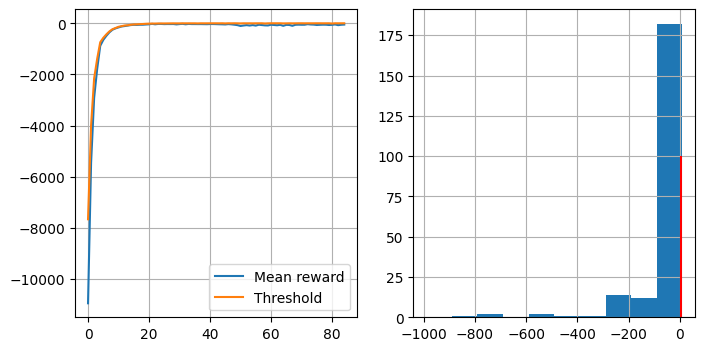

mean reward = -36.500, threshold = 5.000


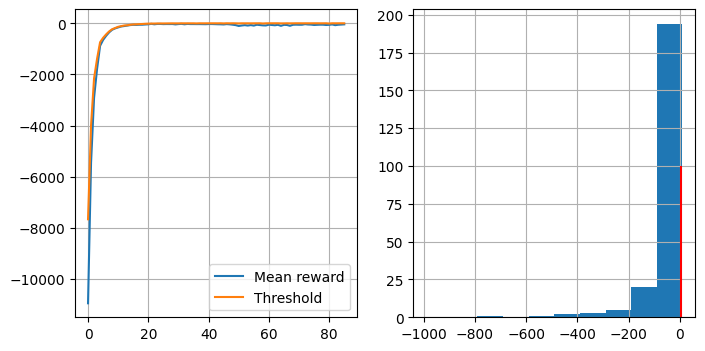

mean reward = -37.868, threshold = 6.500


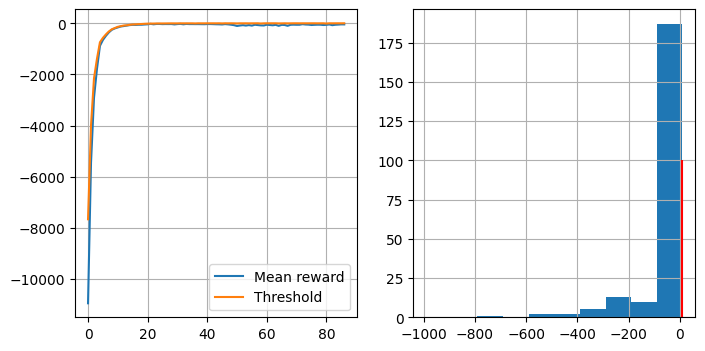

mean reward = -48.208, threshold = 1.000


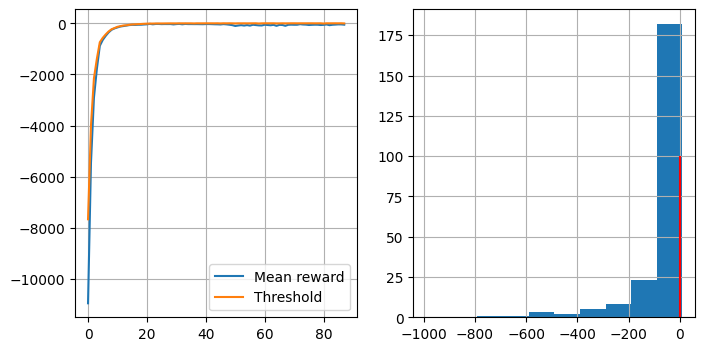

mean reward = -57.756, threshold = 4.500


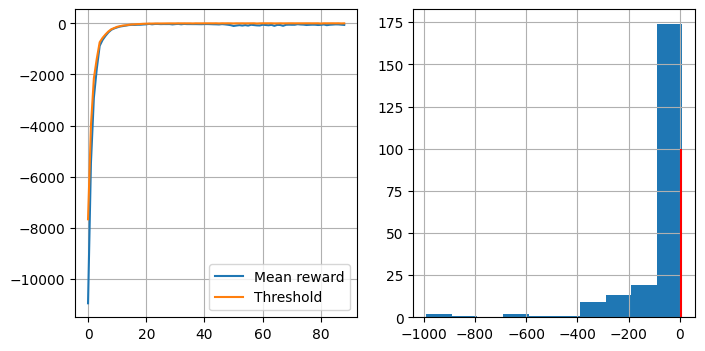

mean reward = -50.532, threshold = 6.000


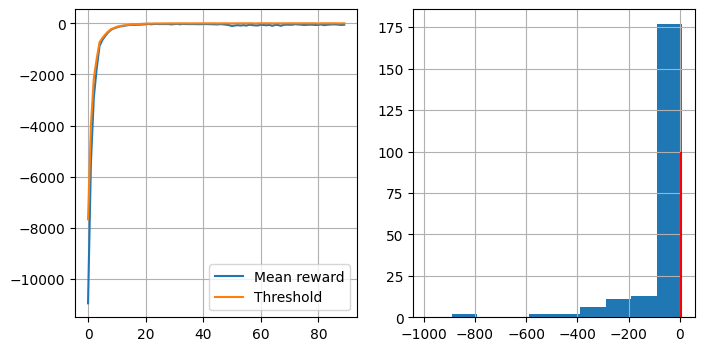

mean reward = -35.328, threshold = 6.000


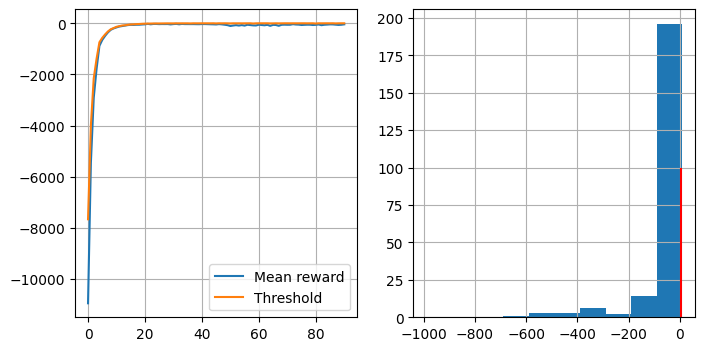

mean reward = -51.592, threshold = 5.000


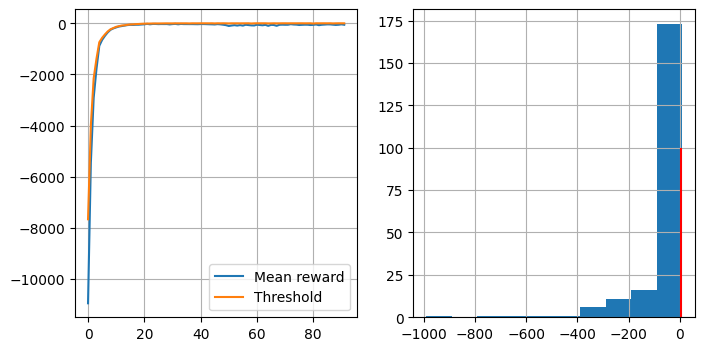

mean reward = -46.952, threshold = 3.000


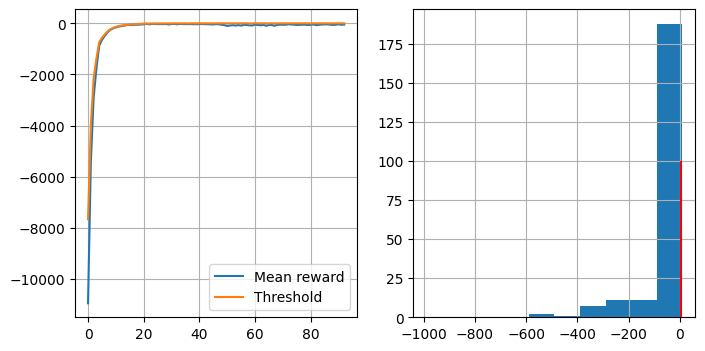

mean reward = -49.580, threshold = 5.000


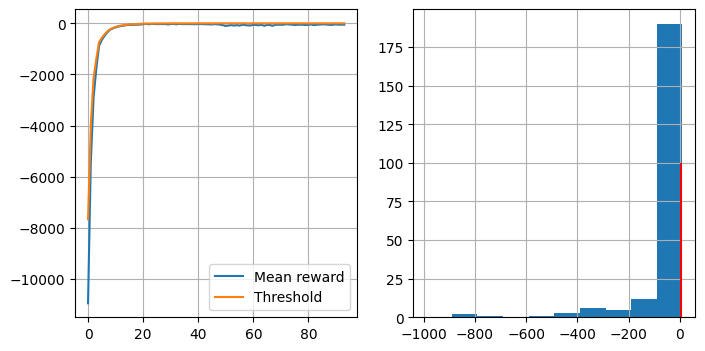

mean reward = -22.436, threshold = 7.000


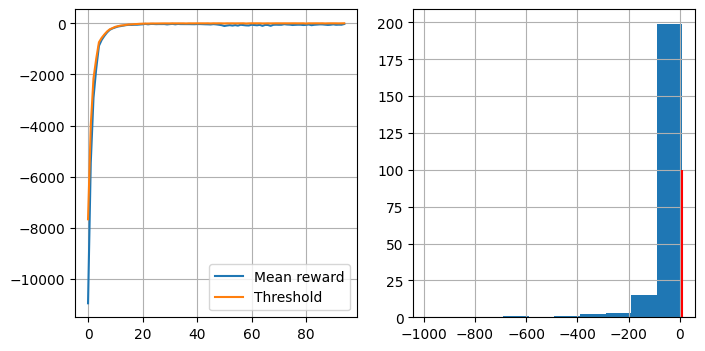

mean reward = -37.116, threshold = 5.000


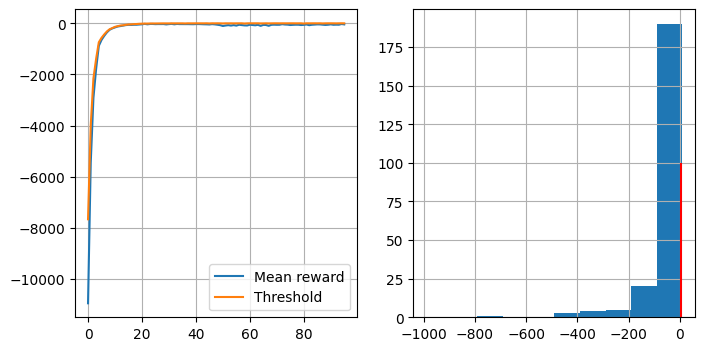

mean reward = -20.584, threshold = 7.000


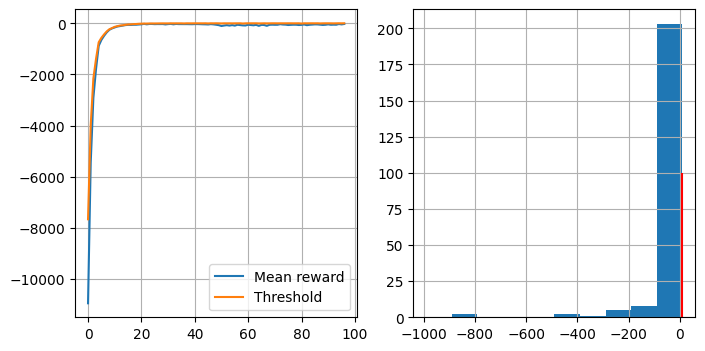

mean reward = -43.096, threshold = 6.000


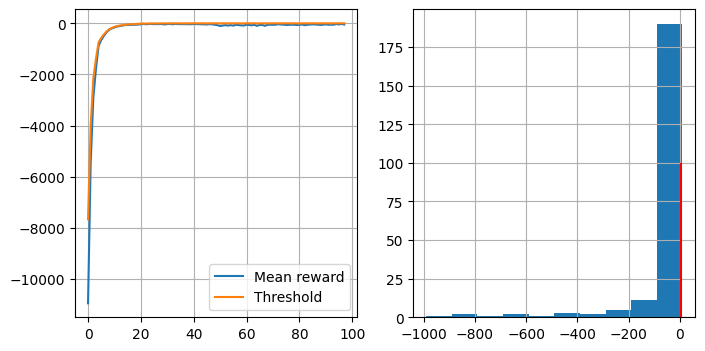

mean reward = -48.776, threshold = 5.500


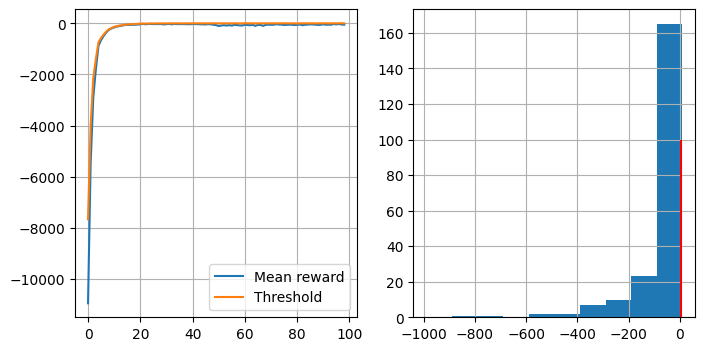

mean reward = -68.728, threshold = 1.000


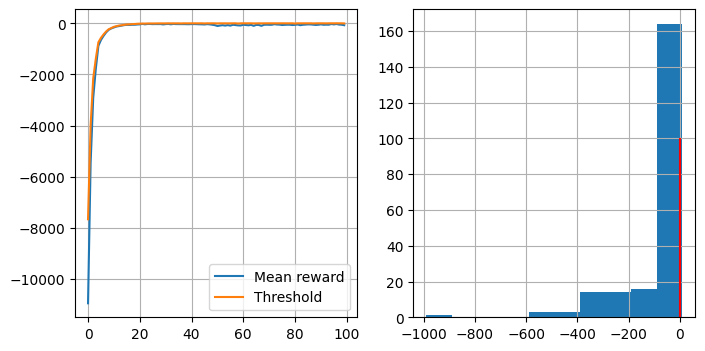

In [8]:
# 7. Основной цикл обучения (CEM)

# Инициализация политики
policy = initialize_policy(n_states, n_actions)

# Параметры обучения
n_sessions = 250       # количество игр за итерацию
percentile = 50        # процент лучших сессий
learning_rate = 0.5    # скорость обновления политики

log = []

# Основной цикл обучения
for i in range(100):

    # Генерация набора сессий
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]

    # Разделение данных
    states_batch, actions_batch, rewards_batch = zip(*sessions)

    # Выбор элитных данных
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )

    # Построение новой политики
    new_policy = get_new_policy(elite_states, elite_actions)

    # Сглаженное обновление (чтобы избежать резких скачков)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # Отображение прогресса
    show_progress(rewards_batch, log, percentile)


1. Начальный этап (Награда < -1000 до ~ -200):
   - Изначальная политика случайна. Агент бесцельно ездит, нарушает правила, и получает огромные штрафы (-10 за каждое
     неправильное действие). Из-за большого пространства состояний (500) и жестких
     штрафов, награда за эпизод низкая (-1000 и ниже).

2. Этап быстрого роста (от -200 до ~ +10):
   - Алгоритм CEM отбирает сессии с наилучшей (наименее плохой) наградой. Даже в
     случайных блужданиях есть те, где агент случайно совершил несколько правильных
     действий подряд.
   - На основе этих "элитных" сессий политика быстро корректируется: агент учится
     избегать самых сильных штрафов и начинает
     двигаться в сторону пассажира или цели.
   - Это приводит к резкому скачку средней награды.

3. Этап стабилизации и небольшого падения (от +10 до -50/-100):
   - После того как агент научился избегать грубых ошибок, политика становится
     более детерминированной. Агент всегда едет по одному и тому же маршруту,
     который он выучил на основе "элитных" эпизодов.
   - Однако Taxi-v3 — стохастическая среда. С вероятностью 1/3 действие может
     быть проигнорировано, и такси поедет в другом направлении. Детерминированная
     политика к этому не готова.
   - Когда из-за "скользкости" такси уезжает не туда, детерминированная политика
     продолжает пытаться ехать по заученному пути (например, нажимать "Юг", когда
     нужно "Север"), что приводит к лишним шагам и, как следствие, к небольшому
     штрафу (-1 за шаг). Поэтому награда падает с оптимальных +10 до -50/-100.
   - CEM не может справиться с этой проблемой, так как он учит фиксированную карту
     действий, а не адаптируется к неопределенности среды. Это демонстрирует
     ограничения табличных методов в стохастических средах.
